# 04. Battery Energy Storage (BESS)

Every model so far has been purely *instantaneous*: at any given hour, the solver could only work
with whatever solar, wind, grid, and load happened to exist in that exact hour. This model introduces
the first **temporal** component — a battery that can move energy from one hour to another.

The objective is to add a **4 MW / 8 MWh battery** to the Model 03 system (10 MW Solar PV + 15 MW
Wind + 6 MW average industrial load + two-directional grid connection). Because the battery links
every snapshot to the next through its state of charge, the solver is no longer optimizing hour by
hour — it has to reason about the *entire year at once* to find the best charge/discharge schedule.

## 🛠️ System Topology
1. **Buses:** A single primary electrical bus, unchanged from Models 01-03.
2. **Generators (Source):** Solar PV (10 MW) and Wind (15 MW), unchanged from Model 03.
3. **Generators (Grid, two-directional):** `Grid_Import` and `Grid_Export`, unchanged from Model 03.
4. **Loads:** The same day/night industrial load from Model 03.
5. **Storage:** A `StorageUnit` — power-limited by `p_nom` (4 MW) and energy-limited by
   `max_hours` (2 hours, giving 8 MWh of usable capacity). Unlike a generator, its dispatch in one
   hour directly affects what it's able to do in every following hour.

With no marginal cost of its own, the battery has only one incentive: **price arbitrage**. It will
charge whenever electricity is cheap or plentiful (high RE, low or negative market price) and
discharge whenever electricity is expensive (low RE, high market price) — either to reduce
`Grid_Import` cost or to increase `Grid_Export` revenue. The solver isn't told to do this explicitly;
it falls directly out of cost-minimization once a device capable of shifting energy in time exists.

<img src="../assets/model_4.jpg" alt="Model 04 System Topology" width="800">


In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Import custom publication-quality plotting style
sys.path.append('../')
from utils.viz_utils import set_nature_style

# Activate global styling
set_nature_style()

# Load processed data
df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

# This completely eliminates any duplicate timestamps caused by Daylight Saving Time.
perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')

# Force all three dataframes to use this clean index
df_pv.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)


## ⚙️ Technical Parameters

The generator, grid, and demand parameters are carried over unchanged from Model 03. A new `battery`
entry defines the storage unit's power rating, duration, and round-trip efficiency.


In [2]:
# Centralized dictionary for technical and economic parameters
tech_param = {
    'solar_pv': {
        'p_nom': 10.0,          # Nominal capacity of the solar PV system in MW
        'marginal_cost': 0.0    # Marginal cost of solar PV generation in $/MWh
    },
    'wind': {
        'p_nom': 15.0,          # Nominal capacity of the wind plant in MW
        'marginal_cost': 0.0    # Marginal cost of wind generation in $/MWh
    },
    'market_grid': {
        'import_p_nom': 20.0,   # Maximum import capacity from the grid
        'export_p_nom': 18.0    # Maximum export capacity to the grid
    },
    'demand': {
        'avg_load_mw': 6.0,     # Average industrial electrical load in MW
        'day_load_mw': 8.0,     # Load during working hours (08:00-18:00)
        'night_load_mw': 4.0    # Load outside working hours
    },
    'battery': {
        'p_nom': 4.0,                # Charge/discharge power rating in MW
        'max_hours': 2.0,            # Duration -> 4 MW x 2h = 8 MWh usable capacity
        'efficiency_store': 0.95,    # Charging efficiency
        'efficiency_dispatch': 0.95  # Discharging efficiency (round-trip ~ 90%)
    }
}


## 🏗️ Initializing the Network

The topology is still a single electrical bus — the battery, like the load, simply attaches to the
same bus as everything else.


In [3]:
# Initialize a new PyPSA network
n = pypsa.Network()
n.set_snapshots(df_pv.index)

# Add the single physical electrical bus
n.add("Bus", "electricity_bus")


Index(['electricity_bus'], dtype='object')

## ⚡ Adding Generators and the Grid Connection

Solar, Wind, `Grid_Import`, and `Grid_Export` are added exactly as in Model 03.


In [4]:
# 1. Add the Solar PV generator
n.add("Generator",
      "Solar_PV",
      bus="electricity_bus",
      p_nom=tech_param['solar_pv']['p_nom'],
      p_max_pu=df_pv['capacity_factor'],
      marginal_cost=tech_param['solar_pv']['marginal_cost'])

# 2. Add the Wind generator
n.add("Generator",
      "Wind",
      bus="electricity_bus",
      p_nom=tech_param['wind']['p_nom'],
      p_max_pu=df_wind['capacity_factor'],
      marginal_cost=tech_param['wind']['marginal_cost'])

# 3. Add the Grid Import generator (covers any shortfall)
n.add("Generator",
      "Grid_Import",
      bus="electricity_bus",
      p_nom=tech_param['market_grid']['import_p_nom'],
      marginal_cost=df_price['price'])

# 4. Add the Grid Export Market Sink (sells any surplus)
n.add("Generator",
      "Grid_Export",
      bus="electricity_bus",
      p_nom=tech_param['market_grid']['export_p_nom'],
      p_min_pu=-1.0,
      p_max_pu=0.0,
      marginal_cost=df_price['price'])


Index(['Grid_Export'], dtype='object')

## 🎯 Adding the Electrical Demand

The same day/night industrial load shape from Model 03.


In [5]:
# Simple day/night industrial load shape - no data file needed
is_daytime = (n.snapshots.hour >= 8) & (n.snapshots.hour < 18)
load_profile = np.where(is_daytime, tech_param['demand']['day_load_mw'], tech_param['demand']['night_load_mw'])
load_profile = pd.Series(load_profile, index=n.snapshots)

n.add("Load", "Industrial_Load", bus="electricity_bus", p_set=load_profile)


Index(['Industrial_Load'], dtype='object')

## 🔋 Adding the Battery

A `StorageUnit` is defined by a power rating (`p_nom`, how fast it can charge or discharge) and a
duration (`max_hours`, how long it can sustain that power before running out), together giving its
usable energy capacity. `cyclic_state_of_charge=True` requires the battery to end the year at the
same state of charge it started with — a standard assumption so the year-long optimization can't
simply drain the battery once for a one-off gain that wouldn't be repeatable year after year.

Note that the battery has **no marginal cost** of its own. Its only incentive to act is the spread
between cheap and expensive hours on the electricity bus — this is what produces arbitrage behavior
without it being explicitly programmed.


In [6]:
n.add("StorageUnit",
      "Battery",
      bus="electricity_bus",
      p_nom=tech_param['battery']['p_nom'],
      max_hours=tech_param['battery']['max_hours'],
      efficiency_store=tech_param['battery']['efficiency_store'],
      efficiency_dispatch=tech_param['battery']['efficiency_dispatch'],
      cyclic_state_of_charge=True)


Index(['Battery'], dtype='object')

## 🧠 Running the Optimization

With a temporal component now in the network, the solver optimizes all 8760 hours as one linked
problem rather than 8760 independent ones — the battery's state of charge at hour *t* constrains what
it can do at hour *t+1*, all the way around the year.


In [7]:
# Optimize the network dispatch using the HiGHS solver
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"Total Objective Value (Net Cost, Import minus Export Revenue): €{n.objective:,.2f}")


Index(['electricity_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 4/4 [00:00<00:00, 23.34it/s]
INFO:linopy.io: Writing time: 1.06s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61320 primals, 140160 duals
Objective: -1.57e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Solver Status: ok
Total Objective Value (Net Cost, Import minus Export Revenue): €-1,569,851.08


## 📊 Analyzing the Results

To see the arbitrage behavior directly, we plot one representative week: the battery's state of
charge alongside the market price it's responding to. A battery doing its job should visibly charge
during price troughs and discharge during price peaks.


Total Renewable Production:    68,182.94 MWh
Grid Import:                   11,850.44 MWh
Grid Export:                   29,754.54 MWh
----------------------------------------
Battery Energy Charged:        5,703.84 MWh
Battery Energy Discharged:     5,065.00 MWh
Round-Trip Losses:             638.84 MWh
----------------------------------------
Grid Import Cost:              €667,751.46
Grid Export Revenue:           €2,237,602.55
Net Cost:                      €-1,569,851.08


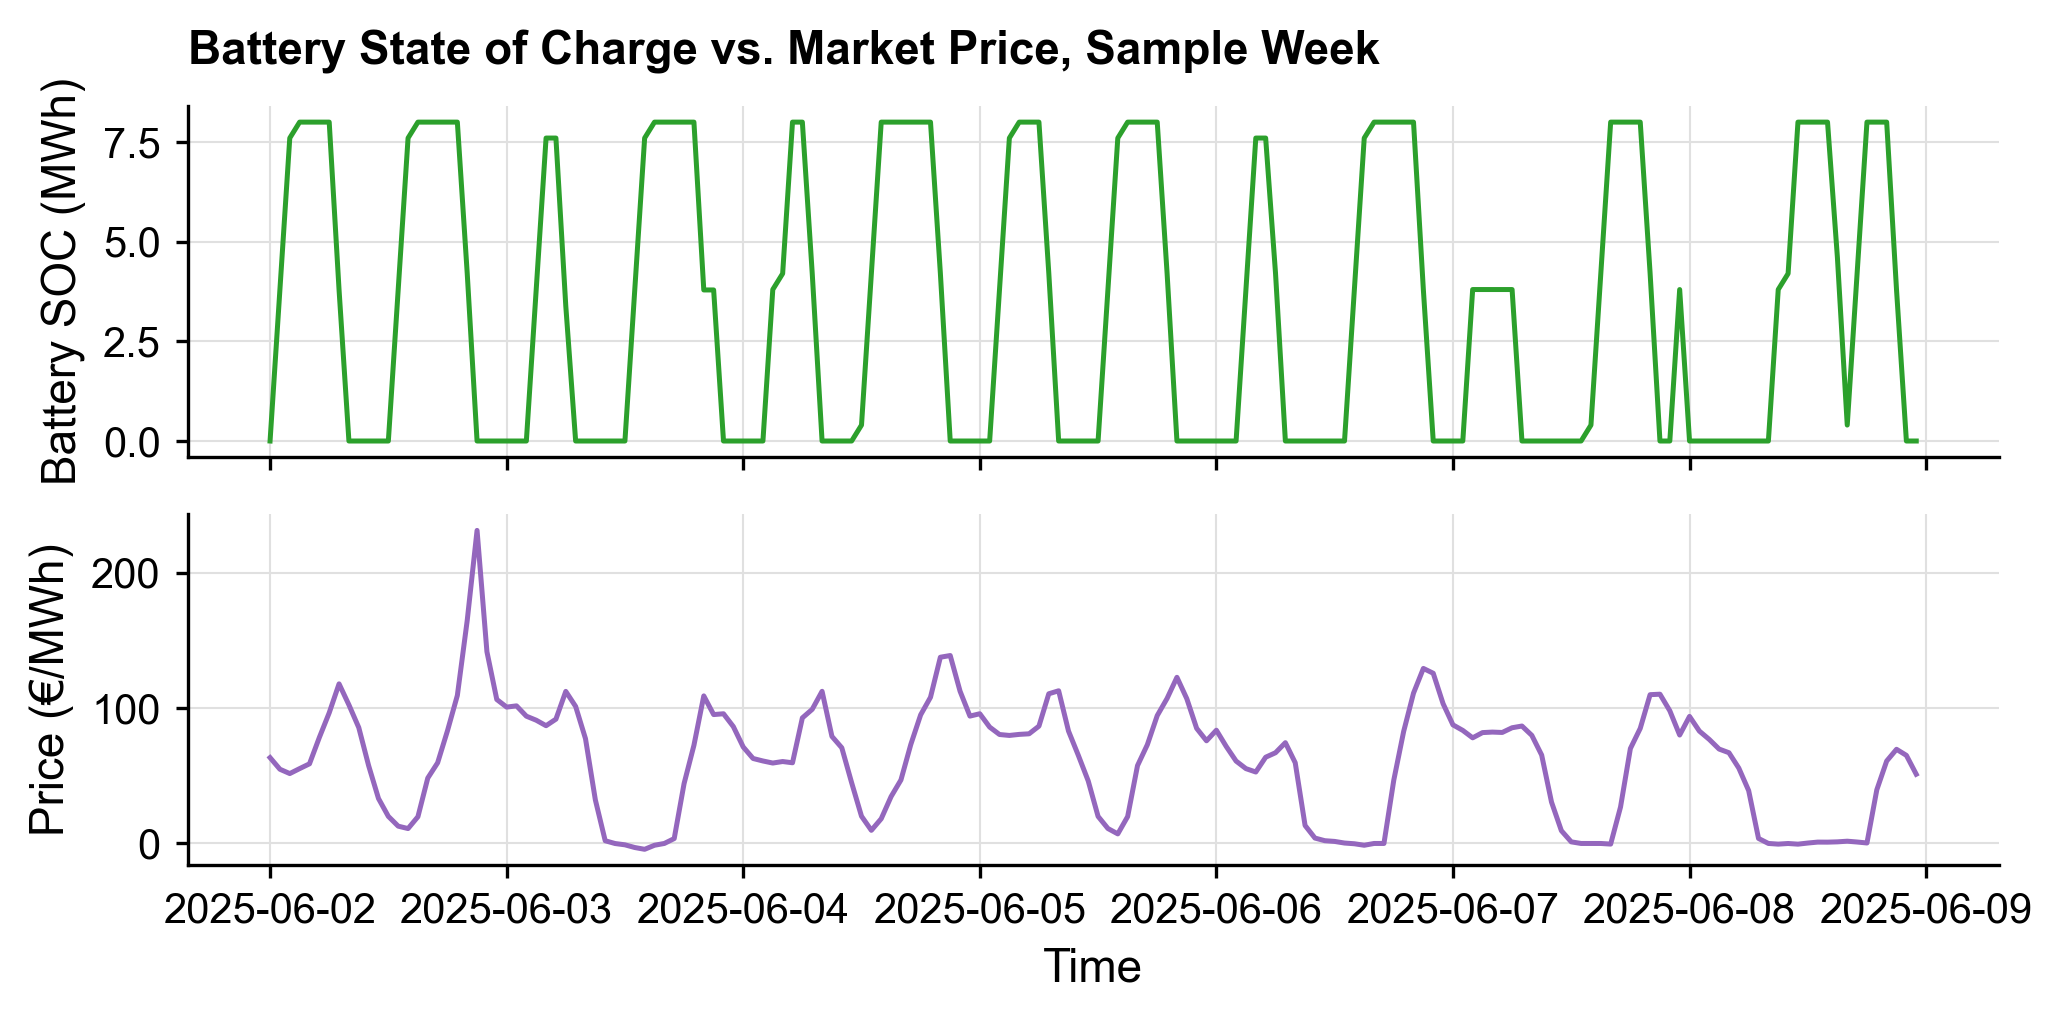

In [8]:
# Calculate Annual Totals
total_solar_mwh = n.generators_t.p['Solar_PV'].sum()
total_wind_mwh = n.generators_t.p['Wind'].sum()
total_import_mwh = n.generators_t.p['Grid_Import'].sum()
total_export_mwh = -n.generators_t.p['Grid_Export'].sum()

battery_charged_mwh = -n.storage_units_t.p['Battery'].clip(upper=0).sum()
battery_discharged_mwh = n.storage_units_t.p['Battery'].clip(lower=0).sum()

import_cost_eur = (n.generators_t.p['Grid_Import'] * df_price['price']).sum()
export_revenue_eur = (n.generators_t.p['Grid_Export'] * -1 * df_price['price']).sum()

print(f"Total Renewable Production:    {total_solar_mwh + total_wind_mwh:,.2f} MWh")
print(f"Grid Import:                   {total_import_mwh:,.2f} MWh")
print(f"Grid Export:                   {total_export_mwh:,.2f} MWh")
print("-" * 40)
print(f"Battery Energy Charged:        {battery_charged_mwh:,.2f} MWh")
print(f"Battery Energy Discharged:     {battery_discharged_mwh:,.2f} MWh")
print(f"Round-Trip Losses:             {battery_charged_mwh - battery_discharged_mwh:,.2f} MWh")
print("-" * 40)
print(f"Grid Import Cost:              €{import_cost_eur:,.2f}")
print(f"Grid Export Revenue:           €{export_revenue_eur:,.2f}")
print(f"Net Cost:                      €{import_cost_eur - export_revenue_eur:,.2f}")

# Plot one representative week: battery state of charge vs. market price
week = (n.snapshots >= '2025-06-02') & (n.snapshots < '2025-06-09')

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(n.snapshots[week], n.storage_units_t.state_of_charge['Battery'][week],
         color='#2ca02c', linewidth=1.2)
ax1.set_ylabel('Battery SOC (MWh)')
ax1.set_title('Battery State of Charge vs. Market Price, Sample Week', pad=10, loc='left', fontweight='bold')

ax2.plot(n.snapshots[week], df_price['price'][week], color='#9467bd', linewidth=1.2)
ax2.set_ylabel('Price (€/MWh)')
ax2.set_xlabel('Time')

plt.tight_layout()
plt.show()
